### Loading Training and Test Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

feature_train = pd.read_csv('X_train_prepared.csv', index_col=0)
target_train  = pd.read_csv('y_train_prepared.csv', index_col=0).squeeze()
feature_test  = pd.read_csv('X_test_processed.csv', index_col=0)
target_test   = pd.read_csv('y_test.csv', index_col=0).squeeze()

### Creating and training the baseline Random Forest model

In [3]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [1, 5, 10],
    'max_features': [0.5, 0.75, 1.0]
}


grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(feature_train, target_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV R²: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters: {'max_depth': None, 'max_features': 0.75, 'min_samples_leaf': 1, 'n_estimators': 200}
Best CV R²: 0.9657


### Evaluating the best model on the test set

In [4]:
best_rf = grid_search.best_estimator_
y_pred_train_rf = best_rf.predict(feature_train)
y_pred_test_rf  = best_rf.predict(feature_test)


In [5]:
mae      = mean_absolute_error(target_test, y_pred_test_rf)
rmse     = np.sqrt(mean_squared_error(target_test, y_pred_test_rf))
r2_train = r2_score(target_train, y_pred_train_rf)
r2_test  = r2_score(target_test, y_pred_test_rf)

print(f"\nTuned Random Forest:")
print(f"MAE:         {mae:.4f}")
print(f"RMSE:        {rmse:.4f}")
print(f"R² on train: {r2_train:.4f}")
print(f"R² on test:  {r2_test:.4f}")


Tuned Random Forest:
MAE:         38.3527
RMSE:        53.0043
R² on train: 0.9961
R² on test:  0.9663


### Plotting for Analysation

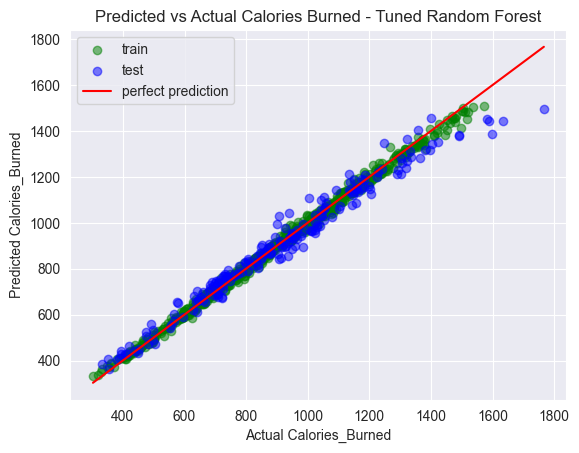

In [6]:
min_val = min(target_train.min(), target_test.min())
max_val = max(target_train.max(), target_test.max())

plt.scatter(target_train, y_pred_train_rf, c='green', label='train', alpha=0.5)
plt.scatter(target_test,  y_pred_test_rf,  c='blue',  label='test',  alpha=0.5)
plt.plot([min_val, max_val], [min_val, max_val], c='red', label='perfect prediction')

plt.xlabel('Actual Calories_Burned')
plt.ylabel('Predicted Calories_Burned')
plt.legend()
plt.title('Predicted vs Actual Calories Burned - Tuned Random Forest')
plt.show()